In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load California Housing (you've seen this dataset since Ch 4)
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} observations, {X_train.shape[1]} features')
print(f'Test set: {X_test.shape[0]} observations')
print(f'Features: {list(X.columns)}')

Training set: 16512 observations, 8 features
Test set: 4128 observations
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [32]:
tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Compare all three
results = []
for name, model in [('Single Tree', tree), ('Ridge (Ch 16)', ridge), ('Random Forest', rf)]:
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train R\u00b2': r2_score(y_train, train_pred),
        'Test R\u00b2': r2_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

               Train RMSE  Test RMSE  Train R²  Test R²
Model                                                  
Single Tree        0.0000     0.7069    1.0000   0.6187
Ridge (Ch 16)      0.7197     0.7455    0.6126   0.5759
Random Forest      0.1880     0.5057    0.9735   0.8049


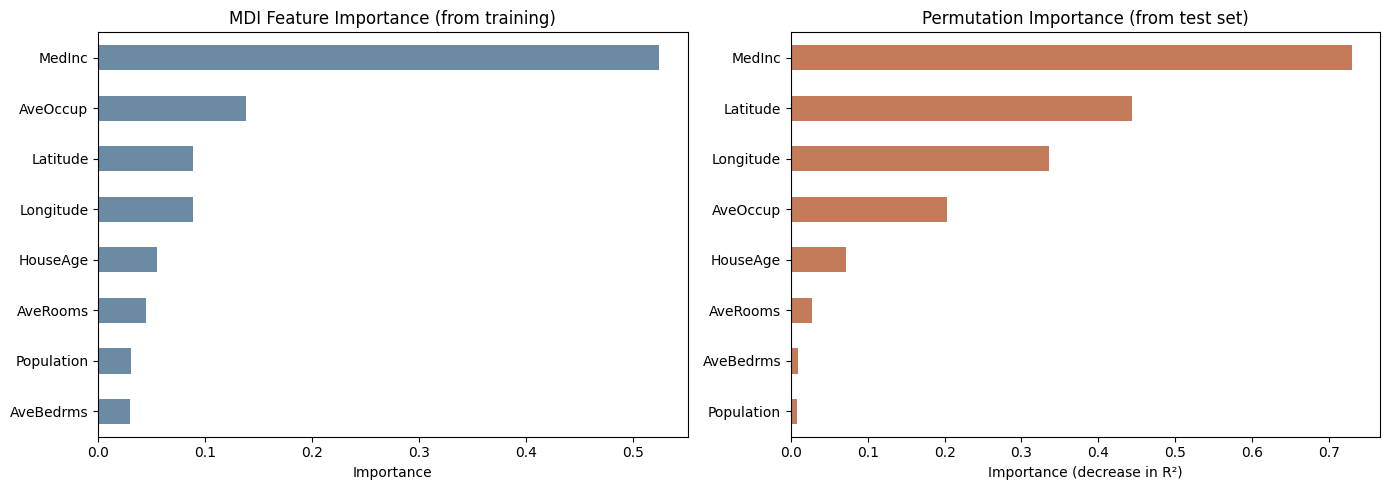


Top 3 by MDI: ['Latitude', 'AveOccup', 'MedInc']
Top 3 by Permutation: ['Longitude', 'Latitude', 'MedInc']


In [33]:
mdi_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mdi_importance.plot.barh(ax=axes[0], color='#6B8BA4')
axes[0].set_title('MDI Feature Importance (from training)', fontsize=12)
axes[0].set_xlabel('Importance')

perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE
)
perm_importance = pd.Series(
    perm_result.importances_mean, index=X.columns
).sort_values(ascending=True)

perm_importance.plot.barh(ax=axes[1], color='#C47B5A')
axes[1].set_title('Permutation Importance (from test set)', fontsize=12)
axes[1].set_xlabel('Importance (decrease in R\u00b2)')

plt.tight_layout()
plt.savefig('figures/ch19_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 by MDI:', mdi_importance.tail(3).index.tolist())
print('Top 3 by Permutation:', perm_importance.tail(3).index.tolist())

In [34]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5, None],  # sqrt = sqrt(p), 0.5 = half, None = all
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=3916),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}')

best_rf = grid_search.best_estimator_
test_rmse = np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test)))
test_r2 = r2_score(y_test, best_rf.predict(X_test))
print(f'Tuned RF — Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}')

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV RMSE: 0.4951
Tuned RF — Test RMSE: 0.4913, Test R²: 0.8158


In [35]:
median_price = np.median(y)
y_binary = (y>median_price).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE
)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=3916)
rf_clf.fit(X_train_c, y_train_c)

log_reg = LogisticRegression(max_iter=1000, random_state=3916)
log_reg.fit(X_train_c, y_train_c)

for name, model in [('Logistic Regression (Ch 17)', log_reg), ('Random Forest', rf_clf)]:
    y_proba = model.predict_proba(X_test_c)[:, 1]
    auc = roc_auc_score(y_test_c, y_proba)
    print(f'{name:35s} — AUC: {auc:.4f}')

# Hyperparameter tuning improved only slightly, decreasing the RMSE from .5 to .49, and increasing the R^2 to .81.

# Yes, the difference is significant, going from .96 to .9.

# I would choose the random forest model due to it having a higher score in predictive accuracy.

Logistic Regression (Ch 17)         — AUC: 0.9087
Random Forest                       — AUC: 0.9611


In [36]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
!pip install anywidget

# --- Assuming X_train, X_test, y_train, y_test, and data are already loaded ---
# Base baseline models for the comparison panel
ridge_model = Ridge(alpha=1.0).fit(X_train, y_train)
tree_model = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)

ridge_r2 = r2_score(y_test, ridge_model.predict(X_test))
tree_r2 = r2_score(y_test, tree_model.predict(X_test))

# --- 1. UI Setup (ipywidgets) ---
# We use sliders to allow the user to dynamically adjust hyperparameters.
n_estimators_slider = widgets.IntSlider(min=1, max=500, step=10, value=50, description='n_estimators:')
max_features_slider = widgets.IntSlider(min=1, max=8, step=1, value=3, description='max_features:')

# --- 2. Figure Setup (Plotly FigureWidget) ---
# FigureWidget is required to integrate seamlessly with ipywidgets for dynamic updates
fig = go.FigureWidget(make_subplots(
    rows=1, cols=3, 
    subplot_titles=('Model Comparison (Test R\u00b2)', 'RF Feature Importance (MDI)', 'Train vs Test R\u00b2 Trajectory'),
    horizontal_spacing=0.08
))

# Panel 1: Model Comparison (Bar Chart)
fig.add_trace(go.Bar(x=['Ridge', 'Single Tree', 'Random Forest'], y=[ridge_r2, tree_r2, 0], 
                     marker_color=['#1f77b4', '#ff7f0e', '#2ca02c']), row=1, col=1)

# Panel 2: Feature Importance (Bar Chart)
fig.add_trace(go.Bar(x=[], y=[], orientation='h', marker_color='#9467bd'), row=1, col=2)

# Panel 3: Train vs Test R2 (Line Chart history)
fig.add_trace(go.Scatter(x=[], y=[], mode='lines+markers', name='Train R\u00b2', line=dict(color='blue')), row=1, col=3)
fig.add_trace(go.Scatter(x=[], y=[], mode='lines+markers', name='Test R\u00b2', line=dict(color='red')), row=1, col=3)

fig.update_layout(height=400, showlegend=False, margin=dict(l=20, r=20, t=40, b=20))
# Fix axis ranges for stability
fig.layout.yaxis.range = [0, 1]
fig.layout.yaxis3.range = [0.5, 1.05]

# State variables to keep track of R2 history for the line chart
history_n_est = []
history_train_r2 = []
history_test_r2 = []

# --- 3. The Callback Function ---
def update_dashboard(change):
    """
    Mechanism Check: This function is triggered every time a slider value changes.
    Because ipywidgets are running in the Python backend, we must re-fit the Random Forest
    model inside this callback to compute the new predictions and feature importances 
    based on the updated hyperparameters. Plotly FigureWidget then pushes these updates 
    to the frontend javascript without reloading the entire cell.
    """
    n_est = n_estimators_slider.value
    max_feat = max_features_slider.value
    
    # Re-fit the model with new parameters
    rf = RandomForestRegressor(n_estimators=n_est, max_features=max_feat, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    # Calculate new metrics
    train_r2 = r2_score(y_train, rf.predict(X_train))
    test_r2 = r2_score(y_test, rf.predict(X_test))
    
    # Update History for Panel 3
    history_n_est.append(n_est)
    history_train_r2.append(train_r2)
    history_test_r2.append(test_r2)
    
    # Get sorted feature importances for Panel 2
    importances = rf.feature_importances_
    indices = np.argsort(importances)
    sorted_features = [data.feature_names[i] for i in indices]
    sorted_importances = importances[indices]
    
    # --- Update the FigureWidget Traces In-Place ---
    with fig.batch_update():
        # Update Panel 1 (RF Bar)
        fig.data[0].y = [ridge_r2, tree_r2, test_r2]
        
        # Update Panel 2 (Feature Importance)
        fig.data[1].x = sorted_importances
        fig.data[1].y = sorted_features
        
        # Update Panel 3 (History Trajectories)
        # We sort by n_estimators so the line draws correctly if the user scrubs back and forth
        sort_idx = np.argsort(history_n_est)
        fig.data[2].x = np.array(history_n_est)[sort_idx]
        fig.data[2].y = np.array(history_train_r2)[sort_idx]
        fig.data[3].x = np.array(history_n_est)[sort_idx]
        fig.data[3].y = np.array(history_test_r2)[sort_idx]

# --- 4. Observers and Initialization ---
# Mechanism Check: .observe binds the update_dashboard function to the 'value' trait of the sliders.
n_estimators_slider.observe(update_dashboard, names='value')
max_features_slider.observe(update_dashboard, names='value')

# Run once to initialize the plots with default slider values
update_dashboard(None) 

# --- 5. Display the UI ---
ui = widgets.VBox([
    widgets.HBox([n_estimators_slider, max_features_slider]), 
    fig
])
display(ui)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.8/574.8 kB 28.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [anywidget]
